In [5]:
import Bio
import itertools
import random
from Bio import SeqIO

In [6]:
import pandas as pd
from Bio.Restriction import AllEnzymes

AllEnzymes

RestrictionBatch(['AanI', 'AarI', 'AasI', 'AatII', 'Aba6411II', 'AbaB8342IV', 'AbaCIII', 'AbaSI', 'AbaUMB2I', 'AbsI', 'Acc16I', 'Acc36I', 'Acc65I', 'Acc65V', 'AccB1I', 'AccB7I', 'AccBSI', 'AccI', 'AccII', 'AccIII', 'AceIII', 'AchA6III', 'AciI', 'AclI', 'AclWI', 'Aco12261II', 'AcoI', 'AcoY31II', 'AcsI', 'AcuI', 'AcvI', 'AcyI', 'AdeI', 'Adh6U21I', 'AfaI', 'AfeI', 'AfiI', 'AflII', 'AflIII', 'AgeI', 'AgsI', 'AhaIII', 'AhdI', 'AhlI', 'AhyRBAHI', 'AhyYL17I', 'AjiI', 'AjnI', 'AjuI', 'AleI', 'AlfI', 'AloI', 'AluBI', 'AluI', 'Alw21I', 'Alw26I', 'Alw44I', 'AlwFI', 'AlwI', 'AlwNI', 'Ama87I', 'AmaCSI', 'Aod1I', 'Aor13HI', 'Aor51HI', 'AoxI', 'ApaBI', 'ApaI', 'ApaLI', 'ApeKI', 'ApoI', 'ApyPI', 'AquII', 'AquIII', 'AquIV', 'ArsI', 'AscI', 'AseI', 'Asi256I', 'AsiGI', 'AsiSI', 'Asp103I', 'Asp114pII', 'Asp700I', 'Asp718I', 'AspA2I', 'AspBHI', 'AspDUT2V', 'AspJHL3II', 'AspLEI', 'AspNIH4III', 'AspS9I', 'AspSLV7III', 'Asu14238IV', 'AsuC2I', 'AsuHPI', 'AsuI', 'AsuII', 'AsuNHI', 'AteTI', 'AvaI', 'AvaII', 'Ava

In [7]:
"""
commerical available enzymes
not sensitive to 6mA or 5mC methylation
that the ovhg that can be compatible with the the sticky end from type IIs RE
do not have amybiguity recognation sequence

do not digest the outside MCS range of the plasmid

can be integrated into the insert animo acid sequence with slience mutation
can have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site

GC content or the hbond number in the sticky end


"""

'\ncommerical available enzymes\nnot sensitive to 6mA or 5mC methylation\nthat the ovhg that can be compatible with the the sticky end from type IIs RE\ndo not have amybiguity recognation sequence\n\ndo not digest the outside MCS range of the plasmid\n\ncan be integrated into the insert animo acid sequence with slience mutation\ncan have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site\n\nGC content or the hbond number in the sticky end\n\n\n'

In [8]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [9]:
"""
commerical available enzymes
not sensitive to 6mA or 5mC methylation
that the ovhg that can be compatible with the the sticky end from type IIs RE
do not have amybiguity recognation sequence

do not digest the outside MCS range of the plasmid

can be integrated into the insert animo acid sequence with slience mutation
can have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site

"""

'\ncommerical available enzymes\nnot sensitive to 6mA or 5mC methylation\nthat the ovhg that can be compatible with the the sticky end from type IIs RE\ndo not have amybiguity recognation sequence\n\ndo not digest the outside MCS range of the plasmid\n\ncan be integrated into the insert animo acid sequence with slience mutation\ncan have slience SNP in the uncut bases that do not change the animo acid sequence but inactivate the RE site\n\n'

In [10]:
import pandas as pd
from Bio.Restriction import AllEnzymes

# Initialize an empty list to store enzyme information
enzyme_data = []

# Iterate through each enzyme in AllEnzymes
for enzyme in AllEnzymes:
    enzyme_info = {
        "Name": enzyme.__name__,
        "Site": enzyme.site,
        "Size": enzyme.size,
        "Is_Palindromic": enzyme.is_palindromic(),
        "Is_Blunt": enzyme.is_blunt(),
        "Is_5Overhang": enzyme.is_5overhang(),
        "Is_3Overhang": enzyme.is_3overhang(),
        "Is_Defined": enzyme.is_defined(),
        "Is_Ambiguous": enzyme.is_ambiguous(),
        "Is_Unknown": enzyme.is_unknown(),
        "Is_Commercially_Available": enzyme.is_comm(),
        "Suppliers": enzyme.suppl,
        "elucidate": enzyme.elucidate(),
    }
    enzyme_data.append(enzyme_info)

# Create a DataFrame from the enzyme data
enzymes_df = pd.DataFrame(enzyme_data)

# Display the DataFrame
enzymes_df

,Name,Site,Size,Is_Palindromic,Is_Blunt,Is_5Overhang,Is_3Overhang,Is_Defined,Is_Ambiguous,Is_Unknown,Is_Commercially_Available,Suppliers,elucidate
0,MbiI,CCGCTC,6,False,True,False,False,True,False,False,True,"(B,)",CCG^_CTC
1,PsrI,GAACNNNNNNTAC,13,False,False,False,True,False,True,False,True,"(I,)","cut twice, not yet implemented sorry."
2,BstSCI,CCNGG,5,True,False,True,False,False,True,False,True,"(I,)",N^CCNGG_N
3,CpoI,CGGWCCG,7,True,False,True,False,False,True,False,True,"(B, K)",CG^GWC_CG
4,Eco81I,CCTNAGG,7,True,False,True,False,False,True,False,True,"(B, K)",CC^TNA_GG
...,...,...,...,...,...,...,...,...,...,...,...,...,...
960,Cau10061II,GTTAAT,6,False,False,False,False,False,False,True,False,(),? GTTAAT ?
961,UbaF11I,TCGTA,5,False,False,False,False,False,False,True,False,(),? TCGTA ?
962,Vtu19109I,CACRAYC,7,False,False,False,False,False,False,True,False,(),? CACRAYC ?
963,ChaI,GATC,4,True,False,False,True,True,False,False,False,(),_GATC^


In [11]:
for enzyme in AllEnzymes:
    enzyme_demo = enzyme

In [12]:
'cut_once', 'cut_twice', 'elucidate', 'fst3', 'fst5','is_3overhang', 'is_5overhang', 'is_ambiguous', 'is_blunt', 'is_comm', 'is_defined','ovhgseq', 'suppl'

('cut_once',
 'cut_twice',
 'elucidate',
 'fst3',
 'fst5',
 'is_3overhang',
 'is_5overhang',
 'is_ambiguous',
 'is_blunt',
 'is_comm',
 'is_defined',
 'ovhgseq',
 'suppl')

In [13]:
print(list(dir(enzyme_demo)))

['__abstractmethods__', '__add__', '__base__', '__bases__', '__basicsize__', '__call__', '__class__', '__delattr__', '__dict__', '__dictoffset__', '__dir__', '__div__', '__doc__', '__eq__', '__flags__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__instancecheck__', '__itemsize__', '__le__', '__len__', '__lt__', '__mod__', '__module__', '__mro__', '__name__', '__ne__', '__new__', '__prepare__', '__qualname__', '__rdiv__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rshift__', '__rtruediv__', '__setattr__', '__sizeof__', '__str__', '__subclasscheck__', '__subclasses__', '__subclasshook__', '__text_signature__', '__truediv__', '__weakrefoffset__', '_drop', '_mod1', '_mod2', '_modify', '_rev_modify', '_search', 'all_suppliers', 'buffers', 'catalyse', 'catalyze', 'charac', 'characteristic', 'compatible_end', 'compsite', 'cut_once', 'cut_twice', 'dna', 'elucidate', 'equischizomers', 'freq', 'frequency

In [14]:
# Check some characteristics that are typical of Type II REs
print(f"Recognition site: {enzyme_demo.site}")
print(f"Cut locations: fst5={enzyme_demo.fst5}, fst3={enzyme_demo.fst3}")
print(f"Is palindromic: {enzyme_demo.is_palindromic()}")
print(f"Is defined site: {enzyme_demo.is_defined()}")

Recognition site: CRTTGAC
Cut locations: fst5=28, fst3=19
Is palindromic: False
Is defined site: False


In [15]:
getattr(Bio.Restriction, "EcoRI").elucidate()

'G^AATT_C'

In [16]:
from Bio.Restriction.Restriction_Dictionary import rest_dict
import numpy as np
import re
from Bio.Seq import Seq
import pandas as pd

In [17]:
df = pd.DataFrame(rest_dict).T

df.drop(columns=["charac", "compsite", "dna", "freq", "fst3", "fst5", "inact_temp", "opt_temp", "results", "scd3", "scd5", "substrat"], inplace=True)

df['name'] = df.index

df_sele = df[
             (df['suppl'].str.len() > 0) & 
             (df.site.str.match('^[ATCG]+$')) & 
             (df.ovhgseq.str.match('^[ATCG]+$')) & 
             (df.ovhg.isin([-5,-4,-3,2,-2]))
            ]

df_sele

,ovhg,ovhgseq,site,size,suppl,name
AbsI,-4,TCGA,CCTCGAGG,8,"(I,)",AbsI
Acc65I,-4,GTAC,GGTACC,6,"(B, I, N, V)",Acc65I
AccIII,-4,CCGG,TCCGGA,6,"(J, K, R)",AccIII
AciI,-2,CG,CCGC,4,"(N,)",AciI
AclI,-2,CG,AACGTT,6,"(I, N, V)",AclI
...,...,...,...,...,...,...
XbaI,-4,CTAG,TCTAGA,6,"(B, C, I, J, K, M, N, Q, R, S, V, X)",XbaI
XhoI,-4,TCGA,CTCGAG,6,"(B, J, K, M, N, O, Q, R, S, X)",XhoI
XmaI,-4,CCGG,CCCGGG,6,"(I, N, R, V)",XmaI
XmaJI,-4,CTAG,CCTAGG,6,"(B,)",XmaJI


In [18]:
rebase_annotated = pd.read_csv('../utils/output/rebase_annotated.csv')

dh5a_compatible_enzyme = rebase_annotated[
    (rebase_annotated['6mA_5mC_sensitive'] == False) &
    (rebase_annotated['enzyme'].notna())
].enzyme.to_list()

dh5a_compatible_prototype = rebase_annotated[
    (rebase_annotated['6mA_5mC_sensitive'] == False) &
    (rebase_annotated['prototype'].notna())
].prototype.to_list()

dh5a_compatible = list(set(dh5a_compatible_enzyme + dh5a_compatible_prototype))

In [19]:
df_sele = df_sele[(df_sele['name'].isin(dh5a_compatible))]
df_sele

,ovhg,ovhgseq,site,size,suppl,name
AbsI,-4,TCGA,CCTCGAGG,8,"(I,)",AbsI
AciI,-2,CG,CCGC,4,"(N,)",AciI
AclI,-2,CG,AACGTT,6,"(I, N, V)",AclI
AflII,-4,TTAA,CTTAAG,6,"(J, K, N)",AflII
AgeI,-4,CCGG,ACCGGT,6,"(J, N, R)",AgeI
...,...,...,...,...,...,...
XbaI,-4,CTAG,TCTAGA,6,"(B, C, I, J, K, M, N, Q, R, S, V, X)",XbaI
XhoI,-4,TCGA,CTCGAG,6,"(B, J, K, M, N, O, Q, R, S, X)",XhoI
XmaI,-4,CCGG,CCCGGG,6,"(I, N, R, V)",XmaI
XmaJI,-4,CTAG,CCTAGG,6,"(B,)",XmaJI


In [20]:
def get_name_from_neb(isoschizomers):
    """
    Get the name of the enzyme from the NEB database.
    :param isoschizomers: List of isoschizomers
    :return: List of enzyme names
    """
    # Initialize an empty list to store enzyme names
    enzyme_names = isoschizomers.split("__")
    enzyme_names = sorted(enzyme_names)

    # Iterate through each isoschizomer
    for enzyme_name in enzyme_names:
        if "N" in getattr(Bio.Restriction, enzyme_name).suppl:
            return enzyme_name

    return enzyme_names[0]

In [21]:
def merge_suppliers(suppliers):
    """Merge supplier lists/tuples into a sorted tuple."""
    merged = set()
    for supp in suppliers:
        merged.update(supp)
    return tuple(sorted(merged))

def merge_group(group):
    """Merge rows in a group:
       - Join 'name' values with '__'
       - Merge supplier info in 'suppl'
    """
    merged_row = group.iloc[0].copy()
    merged_row['name'] = "__".join(group['name'].astype(str))
    merged_row['suppl'] = merge_suppliers(group['suppl'])
    return merged_row

# Group df_sele by 'ovhgseq', 'ovhg', and 'site', and merge each group.
df_sele_grouped = df_sele.groupby(['ovhgseq', 'ovhg', 'site'], as_index=False).apply(merge_group)
df_sele_grouped.reset_index(drop=True, inplace=True)

# Use the first part of the merged 'name' (before '__') as the index.
df_sele_grouped.index = df_sele_grouped['name'].str.split("__").str[0]

# Update df_sele by storing the merged info and simplifying 'name'.
df_sele = df_sele_grouped.copy()
df_sele['isoschizomers'] = df_sele['name']
df_sele['name'] = df_sele.apply(lambda x: get_name_from_neb(x['isoschizomers']), axis=1)
df_sele.index = df_sele['name']
df_sele

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers
name,,,,,,,
TasI,-4,AATT,AATT,4,"(B,)",TasI,TasI
EcoRI,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI
BauI,-4,ACGA,CACGAG,6,"(B, I)",BauI,BauI__Bst2BI
HindIII,-4,AGCT,AAGCTT,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",HindIII,HindIII
PvuI,2,AT,CGATCG,6,"(B, I, K, M, N, O, Q, R, S, X)",PvuI,Ple19I__PvuI
BstKTI,2,AT,GATC,4,"(I,)",BstKTI,BstKTI
RgaI,2,AT,GCGATCGC,8,"(B, I, R)",RgaI,RgaI__SfaAI__SgfI
PacI,2,AT,TTAATTAA,8,"(B, N, O)",PacI,PacI
PciI,-4,CATG,ACATGT,6,"(B, I, N)",PciI,PciI__PscI


In [22]:
df_sele.shape

(60, 7)

In [23]:
df_plasmid = pd.read_csv('../utils/output/plasmid_digest_check.csv', index_col=0)

In [24]:
# Keep only the rows where not every column is False.
#df_plasmid = df_plasmid[~df_plasmid.eq(False).all(axis=1)]
#df_plasmid = df_plasmid[df_plasmid.index.isin(df_sele.index)]
df_plasmid

,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3
EarI,False,False,False,False,False,False,False,False
Bst4CI,False,False,False,False,False,False,False,False
HpyF10VI,False,False,False,False,False,False,False,False
CaiI,False,False,False,False,False,False,False,False
Eam1105I,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...
Aba6411II,False,False,False,False,False,False,False,False
RleAI,False,False,True,True,True,True,True,True
RlaII,False,False,False,False,False,False,False,False
PshBI,False,False,False,False,False,False,False,False


In [25]:
df_sele = df_sele.join(df_plasmid, how='left')
#df_merge = df_merge[df_merge['pET-28a(+)']==True]

# Count the number of True values for each plasmid column in df_merge
plasmid_columns = ['pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)','pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3']
df_sele = df_sele[df_sele[plasmid_columns].any(axis=1)]

df_sele

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3
name,,,,,,,,,,,,,,,
EcoRI,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,True,True,True,True,False
HindIII,-4,AGCT,AAGCTT,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",HindIII,HindIII,True,True,True,True,True,True,True,True
RgaI,2,AT,GCGATCGC,8,"(B, I, R)",RgaI,RgaI__SfaAI__SgfI,True,True,True,False,False,True,True,True
PacI,2,AT,TTAATTAA,8,"(B, N, O)",PacI,PacI,True,True,True,True,True,True,True,True
PciI,-4,CATG,ACATGT,6,"(B, I, N)",PciI,PciI__PscI,False,False,False,False,False,True,False,False
NcoI,-4,CATG,CCATGG,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",NcoI,Bsp19I__NcoI,True,True,True,False,True,True,True,False
AgeI,-4,CCGG,ACCGGT,6,"(B, C, I, J, N, Q, R, V, X)",AgeI,AgeI__AsiGI__BshTI__CspAI__PinAI,True,True,True,True,True,True,True,True
XmaI,-4,CCGG,CCCGGG,6,"(B, I, N, R, V)",XmaI,Cfr9I__XmaI,True,True,True,False,False,True,True,True
MreI,-4,CCGG,CGCCGGCG,8,"(B,)",MreI,MreI,True,True,True,True,True,True,True,True


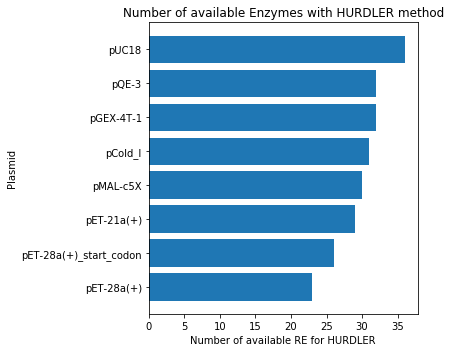

In [26]:
from matplotlib import pyplot as plt
import seaborn as sns

# Prepare the data
true_counts = df_sele[plasmid_columns].sum()
true_counts_sorted = true_counts.sort_values(ascending=True)
true_counts_df = true_counts_sorted.reset_index()
true_counts_df.columns = ['Plasmid', 'True Count']

plt.figure(figsize=(6, 5))
plt.barh(true_counts_df['Plasmid'], true_counts_df['True Count'])
plt.xlabel("Number of available RE for HURDLER")
plt.ylabel("Plasmid")
plt.title("Number of available Enzymes with HURDLER method")
plt.tight_layout()
plt.show()


In [27]:
df_sele['size'].value_counts()

6    31
8     8
7     1
Name: size, dtype: int64

In [28]:
df_sele

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3
name,,,,,,,,,,,,,,,
EcoRI,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,True,True,True,True,False
HindIII,-4,AGCT,AAGCTT,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",HindIII,HindIII,True,True,True,True,True,True,True,True
RgaI,2,AT,GCGATCGC,8,"(B, I, R)",RgaI,RgaI__SfaAI__SgfI,True,True,True,False,False,True,True,True
PacI,2,AT,TTAATTAA,8,"(B, N, O)",PacI,PacI,True,True,True,True,True,True,True,True
PciI,-4,CATG,ACATGT,6,"(B, I, N)",PciI,PciI__PscI,False,False,False,False,False,True,False,False
NcoI,-4,CATG,CCATGG,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",NcoI,Bsp19I__NcoI,True,True,True,False,True,True,True,False
AgeI,-4,CCGG,ACCGGT,6,"(B, C, I, J, N, Q, R, V, X)",AgeI,AgeI__AsiGI__BshTI__CspAI__PinAI,True,True,True,True,True,True,True,True
XmaI,-4,CCGG,CCCGGG,6,"(B, I, N, R, V)",XmaI,Cfr9I__XmaI,True,True,True,False,False,True,True,True
MreI,-4,CCGG,CGCCGGCG,8,"(B,)",MreI,MreI,True,True,True,True,True,True,True,True


In [29]:
unique_RE_sites = list(df_sele.site.unique())

unique_RE_sites_rc = [str(Seq(site).reverse_complement()) for site in unique_RE_sites]

unique_RE_sites = list(set(unique_RE_sites + unique_RE_sites_rc))

len(unique_RE_sites)

40

In [30]:
'''
def re_to_aa(seq):
    """
    Convert a nucleotide sequence to an amino acid sequence.
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]


    # Create a Seq object
    seq_rc = str(Seq(seq).reverse_complement())

    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]
    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_1 = [i[0]+seq_rc+i[1]+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_2 = [i[0]+i[1]+seq_rc+i[2] for i in three_bp_sequences]

    
    seq_ex = [seq, seq_rc] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2 + seq_rc_ex_frame_shift_1 + seq_rc_ex_frame_shift_2

    #print(seq_ex)

    aa_result = [Seq(i).translate() for i in seq_ex]
    aa_result = [str(i) for i in aa_result]
    aa_result = [i for i in aa_result if "*" not in i]
    aa_result = sorted(list(set(aa_result)))

    return aa_result

'''

'\ndef re_to_aa(seq):\n    """\n    Convert a nucleotide sequence to an amino acid sequence.\n    """\n    nucleotides = [\'A\', \'T\', \'G\', \'C\']\n    three_bp_sequences = [\'\'.join(seq) for seq in itertools.product(nucleotides, repeat=3)]\n\n\n    # Create a Seq object\n    seq_rc = str(Seq(seq).reverse_complement())\n\n    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]\n    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]\n    seq_rc_ex_frame_shift_1 = [i[0]+seq_rc+i[1]+i[2] for i in three_bp_sequences]\n    seq_rc_ex_frame_shift_2 = [i[0]+i[1]+seq_rc+i[2] for i in three_bp_sequences]\n\n    \n    seq_ex = [seq, seq_rc] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2 + seq_rc_ex_frame_shift_1 + seq_rc_ex_frame_shift_2\n\n    #print(seq_ex)\n\n    aa_result = [Seq(i).translate() for i in seq_ex]\n    aa_result = [str(i) for i in aa_result]\n    aa_result = [i for i in aa_result if "*" not in i]\n    aa_result = sorted(list(set(aa_resu

In [31]:
df_sele.shape

(40, 15)

In [32]:
df_sele['palindromic'] = df_sele['site'].apply(lambda seq: seq == str(Seq(seq).reverse_complement()))

# For non-palindromic REs, create a reverse complement row
non_pal = df_sele[~df_sele['palindromic']].copy()
non_pal['site'] = non_pal['site'].apply(lambda x: str(Seq(x).reverse_complement()))
non_pal['ovhgseq'] = non_pal['ovhgseq'].apply(lambda x: str(Seq(x).reverse_complement()))
non_pal['name'] = non_pal['name'] + "_rc"
non_pal.index = non_pal.index.astype(str) + "_rc"

# Append the reverse complement rows to the original DataFrame
df_sele = pd.concat([df_sele, non_pal])
df_sele

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3,palindromic
name,,,,,,,,,,,,,,,,
EcoRI,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,True,True,True,True,False,True
HindIII,-4,AGCT,AAGCTT,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",HindIII,HindIII,True,True,True,True,True,True,True,True,True
RgaI,2,AT,GCGATCGC,8,"(B, I, R)",RgaI,RgaI__SfaAI__SgfI,True,True,True,False,False,True,True,True,True
PacI,2,AT,TTAATTAA,8,"(B, N, O)",PacI,PacI,True,True,True,True,True,True,True,True,True
PciI,-4,CATG,ACATGT,6,"(B, I, N)",PciI,PciI__PscI,False,False,False,False,False,True,False,False,True
NcoI,-4,CATG,CCATGG,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",NcoI,Bsp19I__NcoI,True,True,True,False,True,True,True,False,True
AgeI,-4,CCGG,ACCGGT,6,"(B, C, I, J, N, Q, R, V, X)",AgeI,AgeI__AsiGI__BshTI__CspAI__PinAI,True,True,True,True,True,True,True,True,True
XmaI,-4,CCGG,CCCGGG,6,"(B, I, N, R, V)",XmaI,Cfr9I__XmaI,True,True,True,False,False,True,True,True,True
MreI,-4,CCGG,CGCCGGCG,8,"(B,)",MreI,MreI,True,True,True,True,True,True,True,True,True


In [34]:
def get_uncut_bases(site):
    """
    For a given enzyme site elucidation string that uses '^' and '_' as cut markers,
    return a list of indices of the uncut bases (i.e. bases that are not between a pair of markers).

    Each marker toggles the state of being within a cut region.
    
    If the enzyme name ends with '_rc', then the elucidation string is obtained
    from the enzyme with '_rc' removed, and the string is reversed with '^' and '_' swapped.
    
    Args:
        site (str): The enzyme name whose elucidation string is used.
        
    Returns:
        list: List of indices (in the cleaned sequence, with markers removed) for uncut bases.
    """
    if site.endswith('_rc'):
        base_site = site[:-3]  # Remove the "_rc" suffix
        text = getattr(Bio.Restriction, base_site).elucidate()
        # Reverse the text and swap '^' with '_' and vice versa
        swapped_text = []
        for ch in text[::-1]:
            if ch == '^':
                swapped_text.append('_')
            elif ch == '_':
                swapped_text.append('^')
            else:
                complement = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}
                swapped_text.append(complement.get(ch, ch))
        text = ''.join(swapped_text)
    else:
        text = getattr(Bio.Restriction, site).elucidate()

    indices = []
    clean_idx = 0  # index in the cleaned text (ignoring marker characters)
    in_marker = False
    markers = {'^', '_'}
    
    for ch in text:
        if ch in markers:
            in_marker = not in_marker
        else:
            if not in_marker:
                indices.append(clean_idx)
            clean_idx += 1
    return indices

# Example usage:
example_text = 'EcoRI_rc'
print("Outside indices:", get_uncut_bases(example_text))




Outside indices: [0, 5]


In [35]:
# Create a DataFrame with rc column from unique_RE_sites list
nucleotides = ['A', 'T', 'G', 'C']
df_rc = df_sele.copy()
df_rc['snp'] = df_rc.apply(lambda row: nucleotides, axis=1)
df_rc['snp_index'] = df_rc.apply(lambda row: get_uncut_bases(row.name), axis=1)
df_rc['frame_shift'] = df_rc.apply(lambda row: list(range(10-row['size'])), axis=1)
df_rc['padding_bp'] = df_rc.apply(lambda row: [''.join(seq) for seq in itertools.product(nucleotides, repeat=9-int(row['size']))], axis=1)


In [36]:
# Explode the DataFrame for all combinations
df_exploded = df_rc.explode('snp')
df_exploded = df_exploded.explode('snp_index')
df_exploded = df_exploded.explode('frame_shift')
df_exploded = df_exploded.explode('padding_bp')

# Reset the index to have clean row numbers
df_exploded = df_exploded.reset_index(drop=True)

In [37]:
df_exploded.shape

(76416, 20)

In [38]:
df_exploded.snp_index.unique()

array([0, 5, 1, 2, 6, 7, 4], dtype=object)

In [39]:
# Create a randomly reordered version of df
df_random = df_exploded.sample(frac=1).reset_index(drop=True)

# Display the first few rows of the randomized dataframe
df_random.head(5)

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),pET-28a(+),pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3,palindromic,snp,snp_index,frame_shift,padding_bp
0,-4,GATC,TGATCA,6,"(B, C, I, J, K, M, N, O, R, S, V)",BclI,BclI__FbaI__Ksp22I,False,False,False,False,False,False,True,True,True,T,0,0,ATC
1,-4,CCGG,ACCGGT,6,"(B, C, I, J, N, Q, R, V, X)",AgeI,AgeI__AsiGI__BshTI__CspAI__PinAI,True,True,True,True,True,True,True,True,True,G,0,1,TAA
2,-4,CATG,CCATGG,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",NcoI,Bsp19I__NcoI,True,True,True,False,True,True,True,False,True,C,0,2,GGT
3,-4,GATC,AGATCT,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X)",BglII,BglII,True,False,False,False,False,True,True,True,True,C,0,1,TAA
4,-4,TTAA,CTTAAG,6,"(B, C, I, J, K, M, N, S, V)",AflII,AflII__BfrI__BspTI__BstAFI__MspCI__Vha464I,True,True,True,True,True,True,True,True,True,C,0,2,CAG


In [40]:
def create_mutant(row):
    rc_seq = list(row['site'])  # Convert string to list to make it mutable
    mutation_index = int(row['snp_index'])
        
    # Replace character at mutation index with new nucleotide
    rc_seq[mutation_index] = row['snp']
    
    return ''.join(rc_seq)  # Convert back to string

# Add the new column with mutated sequences
df_exploded['site_mutate'] = df_exploded.apply(create_mutant, axis=1)

In [41]:
df_exploded

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),...,pET-28a(+)_start_codon,pCold_I,pUC18,pQE-3,palindromic,snp,snp_index,frame_shift,padding_bp,site_mutate
0,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,...,True,True,True,False,True,A,0,0,AAA,AAATTC
1,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,...,True,True,True,False,True,A,0,0,AAT,AAATTC
2,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,...,True,True,True,False,True,A,0,0,AAG,AAATTC
3,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,...,True,True,True,False,True,A,0,0,AAC,AAATTC
4,-4,AATT,GAATTC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",EcoRI,EcoRI,True,True,True,...,True,True,True,False,True,A,0,0,ATA,AAATTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76411,-3,TGA,GCTGAGG,7,"(N,)",BbvCI_rc,BbvCI,True,True,True,...,True,True,True,True,False,C,6,2,GC,GCTGAGC
76412,-3,TGA,GCTGAGG,7,"(N,)",BbvCI_rc,BbvCI,True,True,True,...,True,True,True,True,False,C,6,2,CA,GCTGAGC
76413,-3,TGA,GCTGAGG,7,"(N,)",BbvCI_rc,BbvCI,True,True,True,...,True,True,True,True,False,C,6,2,CT,GCTGAGC
76414,-3,TGA,GCTGAGG,7,"(N,)",BbvCI_rc,BbvCI,True,True,True,...,True,True,True,True,False,C,6,2,CG,GCTGAGC


In [42]:
def get_frame_shifted(row, column_name):
    # Get the frame shift value
    re_site_seq = row[column_name]
    # Get the 3bp sequence
    three_bp_seq = row['padding_bp']
    # Get the frame shift value
    frame_shift = row['frame_shift']

    shifted_re_site_seq = three_bp_seq[:frame_shift]+ re_site_seq + three_bp_seq[frame_shift:]

    return shifted_re_site_seq

df_exploded['re_site_shifted'] = df_exploded.apply(lambda row: get_frame_shifted(row, 'site'), axis=1)
df_exploded['re_site_mutate_shifted'] = df_exploded.apply(lambda row: get_frame_shifted(row, 'site_mutate'), axis=1)

In [43]:
# Create a randomly reordered version of df
df_random = df_exploded.sample(frac=1).reset_index(drop=True)

# Display the first few rows of the randomized dataframe
df_random.head(5)

,ovhg,ovhgseq,site,size,suppl,name,isoschizomers,pGEX-4T-1,pMAL-c5X,pET-21a(+),...,pUC18,pQE-3,palindromic,snp,snp_index,frame_shift,padding_bp,site_mutate,re_site_shifted,re_site_mutate_shifted
0,2,GC,CCGCGG,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X)",SacII,KspI__SacII__Sfr303I__SgrBI,True,True,True,...,True,True,True,G,0,1,TCG,GCGCGG,TCCGCGGCG,TGCGCGGCG
1,-4,CATG,ACATGT,6,"(B, I, N)",PciI,PciI__PscI,False,False,False,...,False,False,True,C,5,3,TTG,ACATGC,TTGACATGT,TTGACATGC
2,-4,TTAA,CTTAAG,6,"(B, C, I, J, K, M, N, S, V)",AflII,AflII__BfrI__BspTI__BstAFI__MspCI__Vha464I,True,True,True,...,True,True,True,G,0,0,CAA,GTTAAG,CTTAAGCAA,GTTAAGCAA
3,-4,GATC,GGATCC,6,"(B, C, I, J, K, M, N, O, Q, R, S, V, X, Y)",BamHI,BamHI,True,True,True,...,True,True,True,G,0,2,TTC,GGATCC,TTGGATCCC,TTGGATCCC
4,-2,CG,TTCGAA,6,"(B, C, I, J, K, M, N, S, V)",BstBI,AsuII__Bpu14I__Bsp119I__BspT104I__BstBI__NspV_...,False,True,True,...,True,True,True,A,4,2,CCC,TTCGAA,CCTTCGAAC,CCTTCGAAC


In [44]:
df_exploded['re_site_shifted_tl'] = df_exploded['re_site_shifted'].apply(lambda x: str(Seq(x).translate()))
df_exploded['re_site_mutate_shifted_tl'] = df_exploded['re_site_mutate_shifted'].apply(lambda x: str(Seq(x).translate()))

#Seq(dna_seq).translate()

In [45]:
# Create a randomly reordered version of df
df_random = df_exploded.sample(frac=1).reset_index(drop=True)

# Display the first few rows of the randomized dataframe
df_random.head(5).T

,0,1,2,3,4
ovhg,-4,-4,-4,-4,-4
ovhgseq,TCGA,GATC,CTAG,CGCG,TCGA
site,GTCGAC,AGATCT,GCTAGC,GCGCGC,GTCGAC
size,6,6,6,6,6
suppl,"(B, C, I, J, K, M, N, O, Q, R, S, V, X)","(B, C, I, J, K, M, N, O, Q, R, S, V, X)","(B, C, I, J, K, M, N, O, Q, R, S, V, X)","(B, I, J, K, M, N, Q, R, V, X)","(B, C, I, J, K, M, N, O, Q, R, S, V, X)"
name,SalI,BglII,NheI,BssHII,SalI
isoschizomers,SalI,BglII,AsuNHI__NheI,BsePI__BssHII__PauI__PteI,SalI
pGEX-4T-1,True,True,True,False,True
pMAL-c5X,True,False,True,False,True
pET-21a(+),True,False,True,False,True


In [46]:
df_exploded.shape

(76416, 25)

In [47]:
codon_usage_df = pd.read_csv('../utils/output/codon_usage.csv')

In [64]:
codon_usage_df

,codon,frequency
0,TTT,19.7
1,TTC,15.0
2,TTA,15.2
3,TTG,11.9
4,CTT,11.9
...,...,...
57,GGA,9.2
58,GGG,8.6
59,TAA,1.8
60,TAG,0.1


In [77]:
def get_mean_codon_usage(seq):
    """
    Calculate the mean codon usage for a given sequence.
    """
    seq = seq.upper()
    codon_usages = []
    
    for i in range(0, len(seq), 3):
        codon = seq[i:i+3]
        if len(codon) == 3:
            codon_row = codon_usage_df[codon_usage_df['codon'] == codon]
            if not codon_row.empty:
                codon_usages.append(codon_row['frequency'].values[0])
    
    return np.mean(codon_usages) if codon_usages else None

# Test the function
print(get_mean_codon_usage("AAT"))


21.9


In [88]:
df_slient_mutation = df_exploded[
    (df_exploded['site'] != df_exploded['site_mutate']) &
    (df_exploded['re_site_shifted_tl'] == df_exploded['re_site_mutate_shifted_tl']) &
    (~df_exploded['re_site_shifted_tl'].str.contains(r'\*'))
]
df_slient_mutation['codon_usage'] = df_slient_mutation['re_site_mutate_shifted'].apply(get_mean_codon_usage)
df_slient_mutation = df_slient_mutation.loc[df_slient_mutation.groupby(["name", "re_site_shifted_tl"])["codon_usage"].idxmax()]
df_slient_mutation.reset_index(drop=True, inplace=True)

df_slient_mutation['sticky_end_length'] = df_slient_mutation['ovhg'].apply(lambda x: abs(x))
df_slient_mutation['re_name'] = df_slient_mutation['name'].apply(lambda x: x.strip('_rc'))
df_slient_mutation['stick_end_hbond_number'] = df_slient_mutation['ovhgseq'].apply(lambda x: x.count("A")*2+x.count("T")*2+x.count("G")*3+x.count("C")*3)

df_slient_mutation.to_csv('./output/slient_mutation.csv', index=False)

/home/wenzhao/miniconda3/envs/PyRosetta.notebooks/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [89]:
df_no_slient_mutation = df_exploded[
    (~df_exploded['re_site_shifted_tl'].str.contains(r'\*'))
]

df_no_slient_mutation['codon_usage'] = df_no_slient_mutation['re_site_mutate_shifted'].apply(get_mean_codon_usage)
df_no_slient_mutation = df_no_slient_mutation.loc[df_no_slient_mutation.groupby(["name", "re_site_shifted_tl"])["codon_usage"].idxmax()]
df_no_slient_mutation.reset_index(drop=True, inplace=True)

df_no_slient_mutation['sticky_end_length'] = df_no_slient_mutation['ovhg'].apply(lambda x: abs(x))
df_no_slient_mutation['re_name'] = df_no_slient_mutation['name'].apply(lambda x: x.strip('_rc'))
df_no_slient_mutation['stick_end_hbond_number'] = df_no_slient_mutation['ovhgseq'].apply(lambda x: x.count("A")*2+x.count("T")*2+x.count("G")*3+x.count("C")*3)

df_no_slient_mutation.to_csv('./output/no_slient_mutation.csv', index=False)

/home/wenzhao/miniconda3/envs/PyRosetta.notebooks/lib/python3.7/site-packages/ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


In [188]:
def get_re_site(seq):

    seq = seq.upper()
    # Split "HURDLER" into 3-mers
    hurdler_3mers = [seq[i:i+3] for i in range(len(seq) - 2)]

    # Filter rows where any 3-mer is found in the re_site_shifted_tl column
    matching_rows = df_exploded[df_exploded['re_site_shifted_tl'].apply(lambda x: any(mer in x for mer in hurdler_3mers))]

    # Display the matching rows
    print(matching_rows.name.unique())

get_re_site('answeran')

['EcoRI' 'BssHII']


In [190]:
df_no_slient_mutation[(df_no_slient_mutation['name'] =="EcoRI") & (df_no_slient_mutation['re_site_shifted_tl'] == "RAN")].re_site_shifted

Series([], Name: re_site_shifted, dtype: object)

In [171]:
df_no_slient_mutation.columns

Index(['ovhg', 'ovhgseq', 'site', 'size', 'suppl', 'name', 'isoschizomers',
       'pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)',
       'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3', 'palindromic',
       'snp', 'snp_index', 'frame_shift', 'padding_bp', 'site_mutate',
       're_site_shifted', 're_site_mutate_shifted', 're_site_shifted_tl',
       're_site_mutate_shifted_tl', 'codon_usage', 'sticky_end_length',
       're_name', 'stick_end_hbond_number'],
      dtype='object')

In [152]:
df_no_slient_mutation[(df_no_slient_mutation['name'] =="NheI")].re_site_shifted_tl.unique()

array(['AAS', 'ALA', 'ASA', 'ASC', 'ASD', 'ASE', 'ASF', 'ASG', 'ASH',
       'ASI', 'ASK', 'ASL', 'ASM', 'ASN', 'ASP', 'ASQ', 'ASR', 'ASS',
       'AST', 'ASV', 'ASW', 'ASY', 'CAS', 'DAS', 'EAS', 'ELA', 'FAS',
       'GAS', 'GLA', 'HAS', 'IAS', 'KAS', 'KLA', 'LAS', 'LLA', 'MAS',
       'MLA', 'NAS', 'PAS', 'PLA', 'QAS', 'QLA', 'RAS', 'RLA', 'SAS',
       'SLA', 'TAS', 'TLA', 'VAS', 'VLA', 'WAS', 'WLA', 'YAS'],
      dtype=object)

In [183]:
import random
from Bio.Data import CodonTable

def reverse_translate(protein_seq):
    """
    Randomly reverse translate a protein sequence into a DNA sequence.
    
    Args:
        protein_seq (str): Protein sequence (amino acids).
        
    Returns:
        str: Randomly generated DNA sequence.
    """
    # Get the standard codon table
    codon_table = CodonTable.unambiguous_dna_by_id[1]
    
    # Map amino acids to their codons
    aa_to_codons = {}
    for codon, aa in codon_table.forward_table.items():
        if aa not in aa_to_codons:
            aa_to_codons[aa] = []
        aa_to_codons[aa].append(codon)
    
    # Add stop codons
    aa_to_codons['*'] = codon_table.stop_codons
    
    # Generate DNA sequence
    dna_seq = ""
    for aa in protein_seq:
        if aa in aa_to_codons:
            dna_seq += random.choice(aa_to_codons[aa])
        else:
            raise ValueError(f"Invalid amino acid: {aa}")
    
    return dna_seq

# Example usage
protein_sequence = "ANSWER"
protein_sequence = protein_sequence.upper()
dna_sequence = reverse_translate(protein_sequence)
print(f"Protein sequence: {protein_sequence}")
print(f"Randomly reverse translated DNA sequence: {dna_sequence}")

Protein sequence: ANSWER
Randomly reverse translated DNA sequence: GCGAACTCGTGGGAGCGT


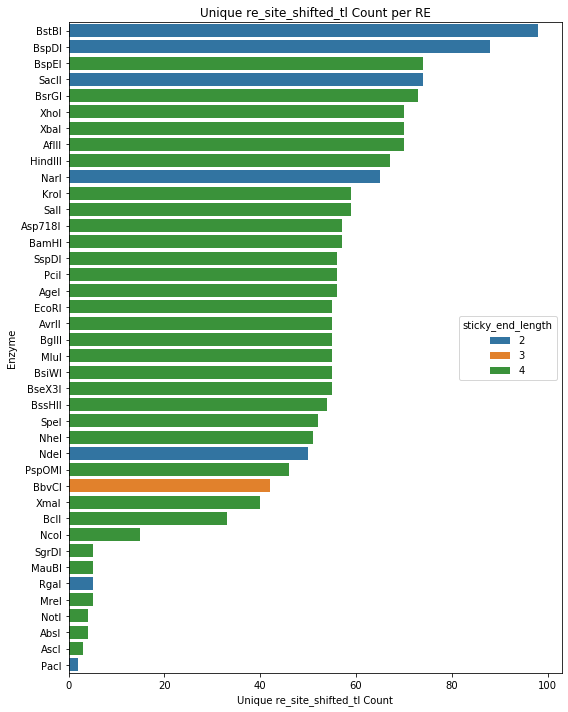

In [ ]:
def get_re_site():
    # Group by enzyme name, calculating number of unique re_site_shifted_tl and taking the first ovhg value
    agg = df_slient_mutation.groupby("re_name").agg(
        count=("re_site_shifted_tl", "nunique"),
        sticky_end_length=("sticky_end_length", "first")
    ).reset_index()
    
    # Sort the data by the count for a cleaner plot
    agg = agg.sort_values("count", ascending=False)
    
    plt.figure(figsize=(8, 10))
    sns.barplot(data=agg, x="count", y="re_name", hue="sticky_end_length", dodge=False)
    plt.xlabel("Unique re_site_shifted_tl Count")
    plt.ylabel("Enzyme")
    plt.title("Unique re_site_shifted_tl Count per RE")
    plt.tight_layout()
    plt.show()

get_re_site()

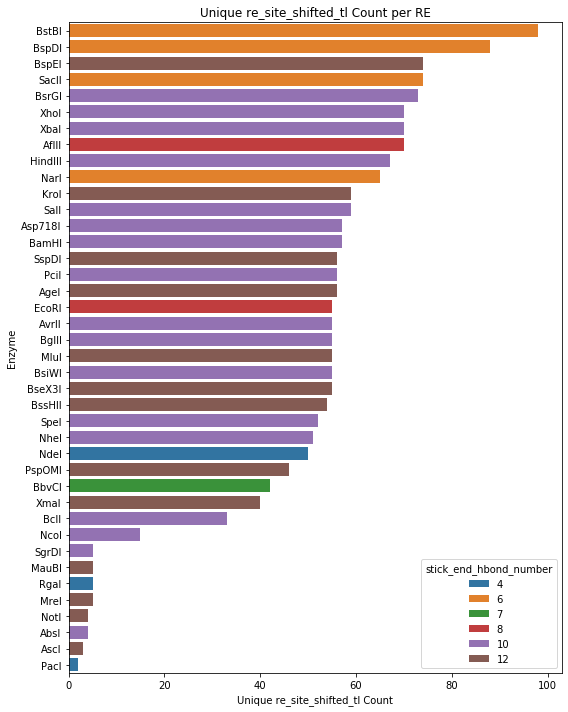

In [ ]:
def get_re_site():
    # Group by enzyme name, calculating number of unique re_site_shifted_tl and taking the first ovhg value
    agg = df_slient_mutation.groupby("re_name").agg(
        count=("re_site_shifted_tl", "nunique"),
        stick_end_hbond_number=("stick_end_hbond_number", "first")
    ).reset_index()
    
    # Sort the data by the count for a cleaner plot
    agg = agg.sort_values("count", ascending=False)
    
    plt.figure(figsize=(8, 10))
    sns.barplot(data=agg, x="count", y="re_name", hue="stick_end_hbond_number", dodge=False)
    plt.xlabel("Unique re_site_shifted_tl Count")
    plt.ylabel("Enzyme")
    plt.title("Unique re_site_shifted_tl Count per RE")
    plt.tight_layout()
    plt.show()

get_re_site()

In [57]:
df_slient_mutation.sample(1).T

,34742
ovhg,-4
ovhgseq,CTAG
site,ACTAGT
size,6
suppl,"(B, I, J, K, M, N, O, Q, R, S, V, X)"
name,SpeI
isoschizomers,AhlI__BcuI__SpeI
pGEX-4T-1,True
pMAL-c5X,True
pET-21a(+),True


In [58]:
df_slient_mutation.to_csv("./output/df_slient_mutation.csv", index=False)

In [59]:
df_slient_mutation.columns

Index(['ovhg', 'ovhgseq', 'site', 'size', 'suppl', 'name', 'isoschizomers',
       'pGEX-4T-1', 'pMAL-c5X', 'pET-21a(+)', 'pET-28a(+)',
       'pET-28a(+)_start_codon', 'pCold_I', 'pUC18', 'pQE-3', 'palindromic',
       'snp', 'snp_index', 'frame_shift', 'padding_bp', 'site_mutate',
       're_site_shifted', 're_site_mutate_shifted', 're_site_shifted_tl',
       're_site_mutate_shifted_tl', 'sticky_end_length', 're_name',
       'stick_end_hbond_number'],
      dtype='object')

In [60]:
re_pet2a8a = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_start_codon = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)_start_codon'] == True)
].re_site_shifted_tl.unique().tolist()

re_pgex = df_slient_mutation[
    (df_slient_mutation['pGEX-4T-1'] == True)
].re_site_shifted_tl.unique().tolist()

re_pmal = df_slient_mutation[
    (df_slient_mutation['pMAL-c5X'] == True)
].re_site_shifted_tl.unique().tolist()

re_puc = df_slient_mutation[
    (df_slient_mutation['pUC18'] == True)
].re_site_shifted_tl.unique().tolist()

re_pqe = df_slient_mutation[
    (df_slient_mutation['pQE-3'] == True)
].re_site_shifted_tl.unique().tolist()

re_pcold = df_slient_mutation[
    (df_slient_mutation['pCold_I'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet21a = df_slient_mutation[
    (df_slient_mutation['pET-21a(+)'] == True)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_4hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=4)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_6hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=6)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_8hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=8)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_10hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=10)
].re_site_shifted_tl.unique().tolist()

re_pet2a8a_12hbond = df_slient_mutation[
    (df_slient_mutation['pET-28a(+)'] == True) &
    (df_slient_mutation['stick_end_hbond_number'] >=12)
].re_site_shifted_tl.unique().tolist()



In [61]:
unique_3mer_list_w_slient_mutation = list(df_slient_mutation.re_site_shifted_tl.unique())

In [62]:
def re_to_aa_with_slient_mutation_inactivate(seq):
    """
    Convert a nucleotide sequence to an amino acid sequence.
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]
    two_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=2)]

    mutated_re = [i[0]+seq[1:-1]+i[1] for i in two_bp_sequences]
    mutated_re = [i for i in mutated_re if i != seq]


    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]
    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]
    
    seq_ex = [seq] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2

    #print(seq_ex)

    aa_result = [Seq(i).translate() for i in seq_ex]
    aa_result = [str(i) for i in aa_result]
    aa_result = [i for i in aa_result if "*" not in i]
    aa_result = sorted(list(set(aa_result)))

    return aa_result

In [63]:
aa_list = []

for re in unique_RE_sites:
    re_rc = str(Seq(re).reverse_complement())
    aa_list = aa_list + re_to_aa(re) + re_to_aa(re_rc)

NameError: name 're_to_aa' is not defined

In [ ]:
unique_aa_list  = list(set(aa_list))
aa_2mer_list = [i for i in unique_aa_list if len(i) == 2]
aa_3mer_list = [i for i in unique_aa_list if len(i) == 3]

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'
aa_2mer_to_3mer_list = []
for aa_2mer in aa_2mer_list:
    for aa in aa_str:
        aa_2mer_to_3mer_list.append(aa_2mer + aa)
        aa_2mer_to_3mer_list.append(aa+aa_2mer)

In [ ]:
unique_3mer_list  = list(set(aa_3mer_list + aa_2mer_to_3mer_list))

In [ ]:
len(unique_3mer_list)

In [ ]:
import random

def generate_random_aa_seq(length):
    """
    Generate a random amino acid sequence of specified length using amino acids from aa_str.
    
    Args:
        length (int): The desired length of the amino acid sequence
        
    Returns:
        str: A random amino acid sequence
    """
    # Generate random sequence by selecting from aa_str
    random_seq = ''.join(random.choice(aa_str) for _ in range(length))
    
    return random_seq

In [ ]:
def check_3mer_in_sequence(sequence, three_mer_list):
    """
    Check if any 3-mer from the list is present in the sequence.
    
    Args:
        sequence (str): The amino acid sequence to check
        three_mer_list (list): List of 3-mer amino acid sequences
        
    Returns:
        bool: True if any 3-mer is found in the sequence, False otherwise
    """
    for three_mer in three_mer_list:
        if three_mer in sequence:
            return True
    return False

In [ ]:
unique_3mer_list_w_slient_mutation

In [ ]:
def check_3mer_in_sequence(sequence, unique_3mer_list_w_slient_mutation):
    """
    Check if any 3-mer from the list is present in the sequence.
    
    Args:
        sequence (str): The amino acid sequence to check
        three_mer_list (list): List of 3-mer amino acid sequences
        
    Returns:
        bool: True if any 3-mer is found in the sequence, False otherwise
    """
    for three_mer in unique_3mer_list_w_slient_mutation:
        if three_mer in sequence:
            return True
    return False

In [ ]:
def calculate_3mer_probability(seq_length, list_3mer, test_num=1000):
    """
    Calculate the probability of finding any 3-mer from unique_3mer_list in random sequences.
    
    Args:
        seq_length (int): Length of random sequences to generate
        test_num (int): Number of test sequences to generate (default: 1000)
    
    Returns:
        float: Probability (percentage) of sequences containing any 3-mer from the list
    """
    # Counter for sequences containing 3-mers
    count = 0
    
    # Generate and test random sequences
    for _ in range(test_num):
        # Generate random sequence
        random_seq = generate_random_aa_seq(seq_length)
        random_seq = random_seq + random_seq[0:2]
        
        # Check if sequence contains any 3-mer from the list
        if check_3mer_in_sequence(random_seq, list_3mer):
            count += 1
    
    # Calculate probability as percentage
    probability = (count / test_num) * 100
    
    print(f"Sequences tested: {test_num}")
    print(f"Sequences with 3-mers: {count}")
    print(f"Probability: {probability:.2f}%")
    
    return probability

In [ ]:
def calculate_multiple_3mer_probabilities(seq_length_list, list_3mer, test_num=1000):
    """
    Calculate 3-mer probabilities for multiple sequence lengths.
    
    Args:
        seq_length_list (list): List of sequence lengths to test
        test_num (int): Number of test sequences for each length (default: 1000)
    
    Returns:
        pandas.DataFrame: DataFrame containing sequence lengths and their corresponding probabilities
    """
    # Create lists to store results
    lengths = []
    probabilities = []
    
    # Calculate probability for each sequence length
    for seq_length in seq_length_list:
        prob = calculate_3mer_probability(seq_length, list_3mer, test_num)
        lengths.append(seq_length)
        probabilities.append(prob)
    
    # Create DataFrame
    results_df = pd.DataFrame({
        'Sequence_Length': lengths,
        'Probability': probabilities
    })
    
    return results_df

In [ ]:
test_num = 1000

hurdler_pet2a8a = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a,test_num=test_num)
hurdler_pet2a8a_start_codon = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_start_codon,test_num=test_num)
hurdler_pgex = calculate_multiple_3mer_probabilities(range(4,51), re_pgex,test_num=test_num)
hurdler_pmal = calculate_multiple_3mer_probabilities(range(4,51), re_pmal,test_num=test_num)
hurdler_puc = calculate_multiple_3mer_probabilities(range(4,51), re_puc,test_num=test_num)
hurdler_pqe = calculate_multiple_3mer_probabilities(range(4,51), re_pqe,test_num=test_num)
hurdler_pcold = calculate_multiple_3mer_probabilities(range(4,51), re_pcold,test_num=test_num)
hurdler_pet21a = calculate_multiple_3mer_probabilities(range(4,51), re_pet21a,test_num=test_num)
hurdler_pet2a8a_4hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_4hbond,test_num=test_num)
hurdler_pet2a8a_6hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_6hbond,test_num=test_num)
hurdler_pet2a8a_8hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_8hbond,test_num=test_num)
hurdler_pet2a8a_10hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_10hbond,test_num=test_num)
hurdler_pet2a8a_12hbond = calculate_multiple_3mer_probabilities(range(4,51), re_pet2a8a_12hbond,test_num=test_num)

In [ ]:
import os

# Create output directory if it doesn't exist
output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the restriction enzyme analysis dataframes
df_slient_mutation.to_csv(os.path.join(output_dir, "df_silent_mutation.csv"), index=False)
true_counts_df.to_csv(os.path.join(output_dir, "true_counts_df.csv"), index=False)

# Save the HURDLER probability dataframes
hurdler_dataframes = {
    "hurdler_pet28a": hurdler_pet2a8a,
    "hurdler_pet28a_start_codon": hurdler_pet2a8a_start_codon,
    "hurdler_pgex": hurdler_pgex,
    "hurdler_pmal": hurdler_pmal,
    "hurdler_puc": hurdler_puc,
    "hurdler_pqe": hurdler_pqe,
    "hurdler_pcold": hurdler_pcold,
    "hurdler_pet21a": hurdler_pet21a,
    "hurdler_pet28a_4hbond": hurdler_pet2a8a_4hbond,
    "hurdler_pet28a_6hbond": hurdler_pet2a8a_6hbond,
    "hurdler_pet28a_8hbond": hurdler_pet2a8a_8hbond,
    "hurdler_pet28a_10hbond": hurdler_pet2a8a_10hbond,
    "hurdler_pet28a_12hbond": hurdler_pet2a8a_12hbond
}

# Save each HURDLER dataframe
for name, df in hurdler_dataframes.items():
    df.to_csv(os.path.join(output_dir, f"{name}.csv"), index=False)

print(f"Successfully saved {len(hurdler_dataframes) + 2} files to {output_dir}/ directory")

In [ ]:
from matplotlib import pyplot as plt


plt.figure(figsize=(8, 4))

# List of plasmid probability DataFrames (excluding those ending with hbond)
plasmid_data = [
    (hurdler_pet2a8a, "pET-28a(+)"),
    (hurdler_pet2a8a_start_codon, "pET-28a(+)_start_codon"),
    (hurdler_pgex, "pGEX-4T-1"),
    (hurdler_pmal, "pMAL-c5X"),
    (hurdler_puc, "pUC18"),
    (hurdler_pqe, "pQE-3"),
    (hurdler_pcold, "pCold_I"),
    (hurdler_pet21a, "pET-21a(+)"),
]

# Plot each plasmid's probability vs sequence length
for data, label in plasmid_data:
    plt.plot(data['Sequence_Length'], data['Probability'],
             marker='o', label=label)

plt.xlabel('Sequence Length')
plt.ylabel('Probability (%)')
plt.title('3-mer Probability vs Sequence Length')
plt.legend(title="Plasmid")
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.plot(hurdler_pet2a8a_4hbond['Sequence_Length'], hurdler_pet2a8a_4hbond['Probability'],
         marker='o', label='≥4 H-bonds')
plt.plot(hurdler_pet2a8a_6hbond['Sequence_Length'], hurdler_pet2a8a_6hbond['Probability'],
         marker='o', label='≥6 H-bonds')
plt.plot(hurdler_pet2a8a_8hbond['Sequence_Length'], hurdler_pet2a8a_8hbond['Probability'],
         marker='o', label='≥8 H-bonds')
plt.plot(hurdler_pet2a8a_10hbond['Sequence_Length'], hurdler_pet2a8a_10hbond['Probability'],
         marker='o', label='≥10 H-bonds')
plt.plot(hurdler_pet2a8a_12hbond['Sequence_Length'], hurdler_pet2a8a_12hbond['Probability'],
         marker='o', label='12 H-bonds')

plt.xlabel('Sequence Length')
plt.ylabel('Probability (%)')
plt.title('3-mer Probability vs Sequence Length for pET-28a(+)')
plt.legend(title='Hydrogen Bond Threshold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
from Bio.Seq import Seq

# Example DNA sequence
dna_seq = "ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG"

# Create a Seq object
coding_dna = Seq(dna_seq)

# Translate to protein
protein_seq = coding_dna.translate()

print(f"DNA sequence: {dna_seq}")
print(f"Protein sequence: {protein_seq}")

In [ ]:
from Bio.Seq import Seq

def get_sequence_and_reverse_complement(sequence):
    # Convert to Seq object if input is string
    if isinstance(sequence, str):
        sequence = Seq(sequence)
    
    # Get reverse complement
    reverse_comp = sequence.reverse_complement()
    
    # Return both sequences in a list
    return [str(sequence), str(reverse_comp)]

# Example usage
test_seq = "ACCTGC"
result = get_sequence_and_reverse_complement(test_seq)
print(f"Original sequence (5' to 3'): {result[0]}")
print(f"Reverse complement (5' to 3'): {result[1]}")


In [ ]:
import itertools
# Generate all possible 3-bp DNA sequences
nucleotides = ['A', 'T', 'G', 'C']
three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]

print(f"Total number of 3-bp sequences: {len(three_bp_sequences)}")
print("First 10 sequences:", len(three_bp_sequences))


In [ ]:
def re_to_aa(seq):
    """
    Convert a nucleotide sequence to an amino acid sequence.
    """
    nucleotides = ['A', 'T', 'G', 'C']
    three_bp_sequences = [''.join(seq) for seq in itertools.product(nucleotides, repeat=3)]


    # Create a Seq object
    seq_rc = str(Seq(seq).reverse_complement())

    seq_ex_frame_shift_1 = [i[0]+seq+i[1]+i[2] for i in three_bp_sequences]
    seq_ex_frame_shift_2 = [i[0]+i[1]+seq+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_1 = [i[0]+seq_rc+i[1]+i[2] for i in three_bp_sequences]
    seq_rc_ex_frame_shift_2 = [i[0]+i[1]+seq_rc+i[2] for i in three_bp_sequences]

    
    seq_ex = [seq, seq_rc] + seq_ex_frame_shift_1 + seq_ex_frame_shift_2 + seq_rc_ex_frame_shift_1 + seq_rc_ex_frame_shift_2

    print(seq_ex)

    aa_result = [Seq(i).translate() for i in seq_ex]
    aa_result = [str(i) for i in aa_result]
    aa_result = [i for i in aa_result if "*" not in i]
    aa_result = sorted(list(set(aa_result)))

    return aa_result





In [ ]:
aa_list = re_to_aa("ACCTGC")

len(aa_list)

In [ ]:
str(aa_list)

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [ ]:
aa_str = 'ACDEFGHIKLMNPQRSTVWY'

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
darmrp_str = 'NEQIQAVIDAGALPALVQLLSSPNEQILQEALWALSNIASGG'
# Create a list to store fragments and their indices
found_fragments = []

# For each fragment in aa_list, find if it appears in darmrp_str
for fragment in aa_list:
    index = darmrp_str.find(fragment)
    if index != -1:
        found_fragments.append((fragment, index))

# Sort by index
found_fragments.sort(key=lambda x: x[1])

# Plot the results
if found_fragments:
    # Create lists for plotting
    fragments = [x[0] for x in found_fragments]
    indices = [x[1] for x in found_fragments]
    
    # Create a bar plot
    plt.figure(figsize=(10, 5))
    plt.bar(fragments, indices)
    plt.xticks(rotation=45)
    plt.xlabel('Fragments')
    plt.ylabel('Position in darmrp_str')
    plt.title('Fragment Positions in darmrp_str')
    plt.tight_layout()
    plt.show()
    
    # Print the results
    print("Found fragments and their positions:")
    for fragment, index in found_fragments:
        print(f"{fragment}: position {index}")
else:
    print("No fragments found in darmrp_str")
